In [1]:
import numpy as np
import matplotlib.pyplot as plt

## divide data 60-20-20

In [3]:
with open('dane.data', 'r') as data, open('training.data', 'w') as training, open('validation.data', 'w') as validation, open('testing.data', 'w') as testing:
    for line in data:
        random_value = np.random.rand()
        if random_value < 0.6:  # 60% chance to go to training
            training.write(line)
        elif random_value < 0.8:  # 20% chance to go to validation
            validation.write(line)
        else:
            testing.write(line)

## divide 50-30-20

In [24]:
with open('dane.data', 'r') as data, open('training.data', 'w') as training, open('validation.data', 'w') as validation, open('testing.data', 'w') as testing:
    for line in data:
        random_value = np.random.rand()
        if random_value < 0.5:  
            training.write(line)
        elif random_value < 0.8:  
            validation.write(line)
        else:
            testing.write(line)

## read_data

In [27]:
def load_data(filename):
    data = np.loadtxt(filename, delimiter='\t')
    X= data[:, :-1]
    y = data[:, -1]
    return X, y
X_train, y_train = load_data('training.data')
X_val, y_val = load_data('validation.data')
X_test, y_test = load_data('testing.data')
mean=X_train.mean(axis=0)
std = X_train.std(axis=0)
min_val = X_train.min(axis=0)
max_val = X_train.max(axis=0)

## scaling

In [12]:
# MIN-MAX SCALING
def scale(X):
    X_scaled = (X - min_val) / (max_val - min_val)
    return X_scaled

In [4]:
# MIN-MAX 2 SCALING
def scale(X):
    X_scaled = (X - mean) / (max_val - min_val)
    return X_scaled

In [5]:
# STANDARIZATION

def scale(X):
    return (X-mean)/std

In [28]:
X_train=scale(X_train)
X_val=scale(X_val)
X_test=scale(X_test)

## different loss functions

In [129]:
# square
def loss_function(a,y):
    return (a-y)**2

In [106]:
# absolute
def loss_function(a,y):
    return abs(a-y)

## Validate

In [7]:
possible_lambdas = [0.01,0.1 , 1 , 10, 100, 1000]

## Regression

In [6]:
def analytic_solution(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    X = np.c_[np.ones(X.shape[0]), X]
    res = np.linalg.inv(X.T @ X) @ X.T @ y
    return res

In [8]:
def analytic_solution_ridge(X: np.ndarray, y: np.ndarray, lam=10) -> np.ndarray:
    X = np.c_[np.ones(X.shape[0]), X]
    d = X.shape[1]
    res = np.linalg.inv(X.T @ X + lam*np.eye(d)) @ X.T @ y
    return res

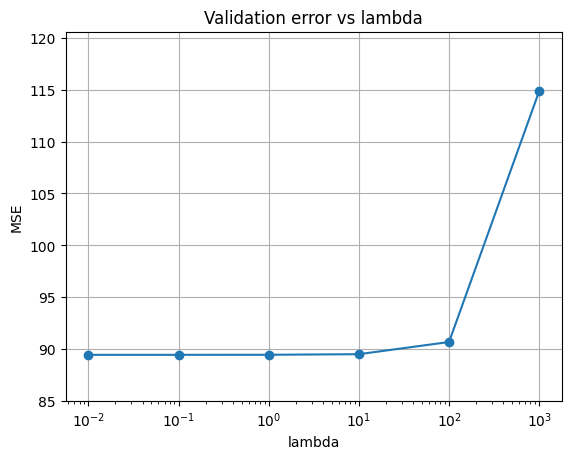

Validation error: 89.41482601197164
for lambda = 0.01


In [107]:
smallest_error=float("inf")
best_lambda=-1
best_solution=None
lambdas=[]
errors=[]
for l in possible_lambdas:
    try:
        solution = analytic_solution_ridge(X_train, y_train,lam=l)
    except:
        print(f"singular matrix for lambda = {l}")
    error = 0
    X_val_bias = np.c_[np.ones(X_val.shape[0]), X_val]
    y_pred = X_val_bias @ solution
    
    error = np.mean((loss_function(y_pred,y_val)))
    lambdas.append(l)
    errors.append(error)
    if error<smallest_error:
        smallest_error=error
        best_lambda=l
        best_solution=solution
plt.plot(lambdas, errors, marker='o')
plt.xlabel("lambda")
plt.ylabel("MSE")
plt.title("Validation error vs lambda")
plt.ylim(min(errors)*0.95, max(errors)*1.05)
plt.xscale("log")
plt.grid()
plt.show()
print("Validation error:", smallest_error)
print(f'for lambda = {best_lambda}')

## ANALYTICAL_SOLVE

## Gradient

In [25]:
# modify here for different learning rate
eta = 0.0001

In [31]:
# gradient descent for ridge regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @ (X @ theta - y)
    grad[1:] +=lamb * theta[1:]
    return eta*grad

In [ ]:
# gradient descent for lasso regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @(X @ theta - y)
    grad[1:]+= lamb*np.sign(theta[1:])
    return eta * grad

In [102]:
# gradient descent for elastic net regression
def compute_theta(theta,X,y,lamb):
    grad = X.T @(X @ theta - y)
    grad[1:]+= lamb*np.sign(theta[1:])
    grad[1:] +=lamb * theta[1:]
    return eta * grad


In [99]:
def gradient_descent(X, y, lamb, num_iterations=100):
    X = np.c_[np.ones(X.shape[0]), X]
    theta = np.random.random(X.shape[1]) 
    for _ in range(num_iterations):
        theta -= compute_theta(theta,X,y,lamb)
    return theta

## validate with gradient

In [127]:
def validate(X_train, y_train):
    smallest_error = float("inf")
    best_lambda = None
    best_solution = None
    lambdas = []
    errors = []

    for l in possible_lambdas:
        solution = gradient_descent(X_train, y_train, l)
        X_val_bias = np.c_[np.ones(X_val.shape[0]), X_val]
        y_pred = X_val_bias @ solution
        error = np.mean(loss_function(y_pred, y_val))

        lambdas.append(l)
        errors.append(error)

        if error < smallest_error:
            smallest_error = error
            best_lambda = l
            best_solution = solution

    print("Validation error:", smallest_error)
    print(f"for lambda = {best_lambda}")
    return best_solution
# plt.plot(lambdas, errors, marker='o')
# plt.xlabel("lambda")
# plt.ylabel("MSE")
# plt.title("Validation error vs lambda")
# plt.ylim(min(errors)*0.95, max(errors)*1.05)
# plt.xscale("log")
# plt.grid()
# plt.show()
# print("Validation error:", smallest_error)
# print(f'for lambda = {best_lambda}')

## TEST_FOUND_DATA

In [137]:
def test(X,y):
    best_solution=validate(X,y)
    error = 0
    for i in range(X_test.shape[0]):
        x = np.insert(X_test[i], 0, 1)
        a = best_solution @ x
        error += loss_function(a, y_test[i])
    error /= X_test.shape[0]
    return error

## model learning curve

Validation error: 49342.50051333796
for lambda = 1000
Validation error: 42726.11155137012
for lambda = 1000
Validation error: 33577.61167027733
for lambda = 0.1
Validation error: 17831.29557501481
for lambda = 1
Validation error: 10985.80458255976
for lambda = 0.01
Validation error: 11043.077158288283
for lambda = 0.01
[np.float64(47895.095344462876), np.float64(41289.02871673112), np.float64(33551.665939995284), np.float64(17564.74959263178), np.float64(10731.446777473406), np.float64(10773.378296612605)]


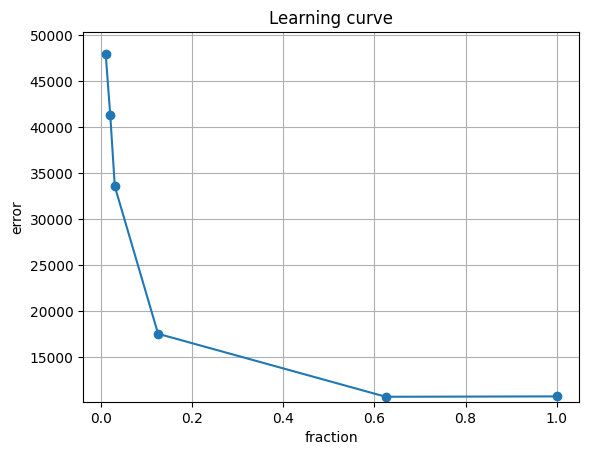

In [142]:
fractions=[0.01,0.02,0.03,0.125,0.625,1]
errors=[]
for f in fractions:
    n = max(1, int(len(X_train) * f))
    indices = np.random.choice(len(X_train), size=n, replace=False)
    X = X_train[indices]
    y = y_train[indices]
    errors.append(test(X, y))
print(errors)
plt.plot(fractions, errors, marker='o')
plt.xlabel("fraction")
plt.ylabel("error")
plt.title("Learning curve")
plt.ylim(min(errors)*0.95, max(errors)*1.05)
plt.grid()
plt.show()